# Segmentation

Segmentation is a fundamental task in point cloud processing, where **the goal is to partition a pointcloud into meaningful regions or segments**. This notebooks covers "traditional" or geometric segmentation techniques for surface segmentation and object segmentation.

The first part focuses on **surface segmentation**, which involves isolating and potentially identifying different surfaces within a pointcloud, with three of the most popular surface segmentation algorithms: **Region Growing, the Hough Transform, and RANSAC**. Segmented surfaces provide a higher level of abstraction than a mere collection of 3D points, which may be used later for further analysis or processing.

The second part is about **object segmentation** and isolating parts of the pointcloud consisting of distinct objects using groups of close points. This is often referred as **graph-based segmentation** and used as a baseline for more advanced techniques such as object recognition.

Note that other types of segmentation tasks are not described in this notebook. These include more advanced *object segmentation* tasks, but also *instance segmentation* (separating individual instances of objects within a pointcloud) and *semantic segmentation* (assigning semantic labels to each point in the pointcloud, such as "car", "tree", or "building"). These tasks often rely on machine learning and deep learning models, which have gained popularity due to their ability to handle complex and varied data. These will be convered in the next notebooks.


In [21]:
# Necessary imports
import numpy as np
from scipy import ndimage
from scipy.spatial import KDTree
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt

# Load pointcloud
data = np.loadtxt("./data/indoor_scene.xyz")
points, colors = data[:, :3], data[:, 6:]
# Build the kd-tree (for neighbor search) once
kdtree = KDTree(points)


For the sake of illustration, let's consider a synthetic pointcloud representing an indoor scene, represented below. This scene is composed of 8 "objects": 1 floor (grey), 2 walls (beige), 1 drawer (brown), 1 pipe (grey), 1 ball (blue), 1 stool (red), and 1 plant in a pot (terracotta and green). Each of these object having one or more surfaces.


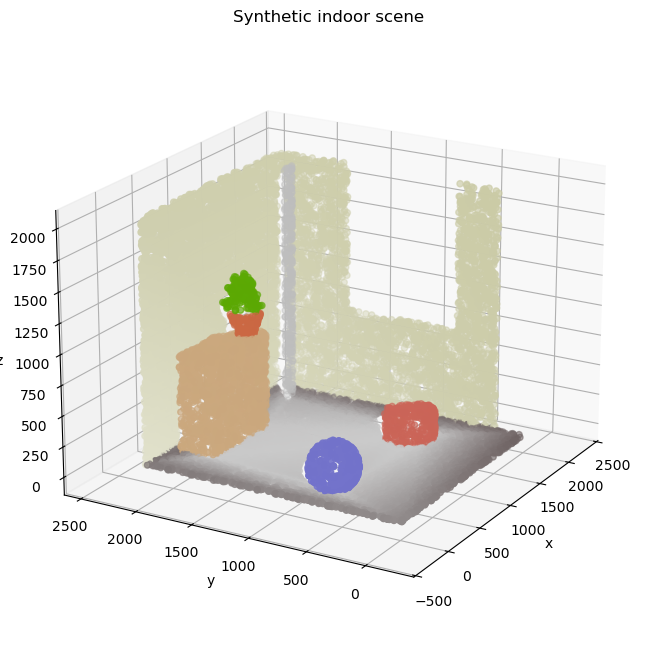

In [22]:
# Plot original pointcloud
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          c=colors)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(20, 210)
plt.axis("equal")
plt.title("Synthetic indoor scene")
plt.show()


## Surface segmentation

### Region growing

The region growing algorithm is one popular segmentation algorithm, whether for images, pointclouds or meshes. It works by **iteratively aggregating similar points**, in a bottom-up fashion.

This algorithm is fairly simple, with just two main steps:

1. Creation of a region by the selection of a starting element (or *seed*).
2. Growth of this region by incorporating similar elements from its neighborhood.

The growth phase stops when the elements in the region's neighborhood can no longer be incorporated. The algorithm is usually repeated until every point of the pointcloud has been assigned to a region ($n$ repetitions resulting in $n$ regions).

Note that **the algorithm requires the prior definition the notions of similarity and neighborhood**. Numerous indicators may be used to assess similarity, alone or in combination, such as normals, colors, or local curvature. Similarly, the notion of neighborhood may take various definitions, such as k-nearest neighborhood, spherical neighborhood, or planar neighborhood.

An algorithm capable of segmenting a pointcloud into a set of smooth surface patches is for example described in the paper: Rabbani, T., Van Den Heuvel, F., & Vosselmann, G. (2006). Segmentation of point clouds using smoothness constraint. *International archives of photogrammetry, remote sensing and spatial information sciences*, 36(5), 248-253.

This *smoothness constraint* "uses local surface normals and point connectivity which can be enforced using either k-nearest or fixed distance neighbors". The first is preferred by the authors for its adaptability to local point density.

According to the authors, normals are a good and reliable measure of local geometry, unlike principal curvatures and other high order geometrical descriptors which are more sensitive to noise. Normals are estimated by fitting a plane to the local neighborhood of a given point (see the next notebook for more details).

The residual of the plane fitting is taken as an approximation of the local curvature. Indeed, this value is equal to the sum of squared distances between the points and the fitted plane. Hence, the higher the residual, the more the surface sampled by the points deviate from a plane.

Note that both normals and residuals are affected by the kind and the size of the considered local neighborhood.


In [23]:
def compute_normals_residuals(points, neighbor_finding_function):
    """Compute normals and residuals from tangent plane estimation."""

    normals = np.empty(points.shape, dtype=float)
    residuals = np.empty(len(points), dtype=float)

    # Local connectivity
    neighbors = neighbor_finding_function(points)
    # Local plane fitting
    for j, inds in enumerate(neighbors):    
        centroid = points[inds].mean(axis=0)
        X = points[inds] - centroid
        cov = X.T @ X
        w, v = np.linalg.eigh(cov)
        residuals[j] = w[0]
        normals[j] = v[:, 0] # eigenvectors are normalized

    return normals, residuals


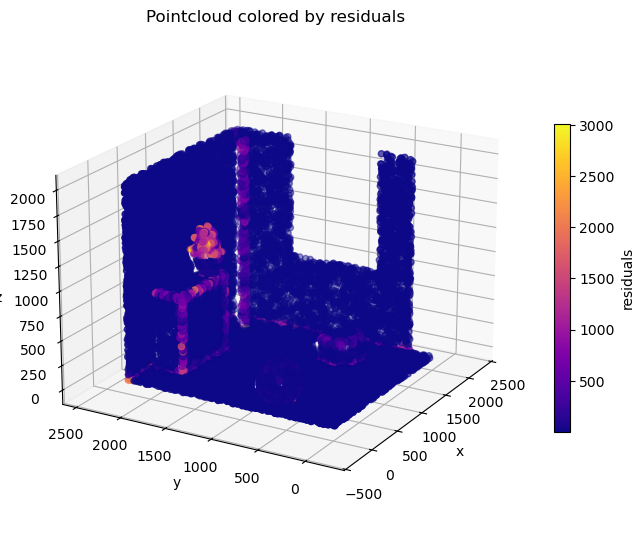

In [24]:
# Compute and plot residuals
def neighbor_finding_function(x): return kdtree.query(x, k=10)[1]
# for spherical neighborhood: return kdtree.query_ball_point(x, r=10.) 
normals, residuals = compute_normals_residuals(points, neighbor_finding_function)

# Plot pointcloud colored by residuals
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          c=residuals, cmap="plasma")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(20, 210)
cbar = fig.colorbar(p, shrink=0.5)
cbar.set_label('residuals')
plt.axis("equal")
plt.title("Pointcloud colored by residuals")
plt.show()

The estimated normals and residuals are then used for the region growing process:
1. The neighbor $p_j$ of $p_i$ is added to the growing region only if the cosine of the angle between their normals is over given threshold: $|n_i \cdot n_j| > \cos(\theta_{th})$
2. A neighbor of $p_j$ is considered a suitable candidate for the next steps of the growing phase only if its residual is below a given threshold: $r_j < r_{th}$

In the first expression, the absolute value of the dot product is taken due to inconsistent orientation between normals (normals are estimated with a 180° ambiguity). Normals are also supposed to be unit vectors.

The authors of the article propose to use an absolute value for $\theta_{th}$ and a relative value for $r_{th}$, which is a less intuitive parameter.


In [25]:
# Angle threshold (in degrees)
angle_threshold = 15.
# Residual threshold (as a percentile of the plane residuals)
residual_threshold = np.percentile(residuals, 95)


Once the neighborhood and thresholds have been defined and the normals and residuals have been approximated, the region growing phase may begin. The seed is here chosen as the not-already-segmented point with the minimum residual and the growth phase is realized according to the angular and residual conditions described above.

The process stops when each point of the pointcloud has been attributed to a segment/region.


In [ ]:
def region_growing(points, normals, residuals, neighbor_finding_function, angle_threshold, residual_threshold):
    """Region growing segmentation algorithm.
    
    Parameters
    ----------
    points : (N, 3) ndarray
        Pointcloud to segment.
    normals : (N, 3) ndarray
        Normals associated to each point.
    residuals : (N,) ndarray
        Residuals associated to each point.
    neighbor_finding_function : function
        Function that takes a point as input and returns the indices of its neighbors.
    angle_threshold : float
        Maximum angle (in degrees) between normals of neighboring points to be included in the same region
    residual_threshold : float
        Maximum residual for a point to be considered as a seed for region growing.
        
    Returns
    -------
    regions : list of ndarray
        List of regions, each region being represented by the indices of its points in the input pointcloud.
    """
    
    # All points are available at start
    available_points = np.ones(len(points), dtype=bool)
    regions = []

    while available_points.any():
        # Current region is empty
        current_region = np.zeros(len(points), dtype=bool)
        # Point (index) with minimal residual is chosen as seed
        remaining_points = np.flatnonzero(available_points)
        seed = remaining_points[np.argmin(residuals[available_points])]
        current_seeds = [seed] # works as a queue
        # Remove seed from available points
        available_points[seed] = False
        # Include seed to current region
        current_region[seed] = True
    
        while len(current_seeds):        
            # Find nearest neighbors of current seed point
            seed = current_seeds.pop(0)
            neighbors = neighbor_finding_function(points[seed])
            
            for neighbor in neighbors:
                
                # Neighbors with orientation close to the seed are added to the current region
                # absolute value because normals have a 180° ambiguity 
                abs_cos = np.abs(normals[neighbor] @ normals[seed]).clip(0., 1.)
                angle = np.arccos(abs_cos) * 180/np.pi # in degrees
                if available_points[neighbor] and (angle < angle_threshold):
                    current_region[neighbor] = True
                    available_points[neighbor] = False
                    
                    # Neighbors with small residuals are potential seeds
                    if residuals[neighbor] < residual_threshold:
                        current_seeds.append(neighbor)
    
        regions.append(np.flatnonzero(current_region))

    return sorted(regions, key=len, reverse=True) # sort according to region size


As seen below, smooth surfaces are well segmented, leaving edges and irregular surfaces (such as plant leaves) in the "others" category.

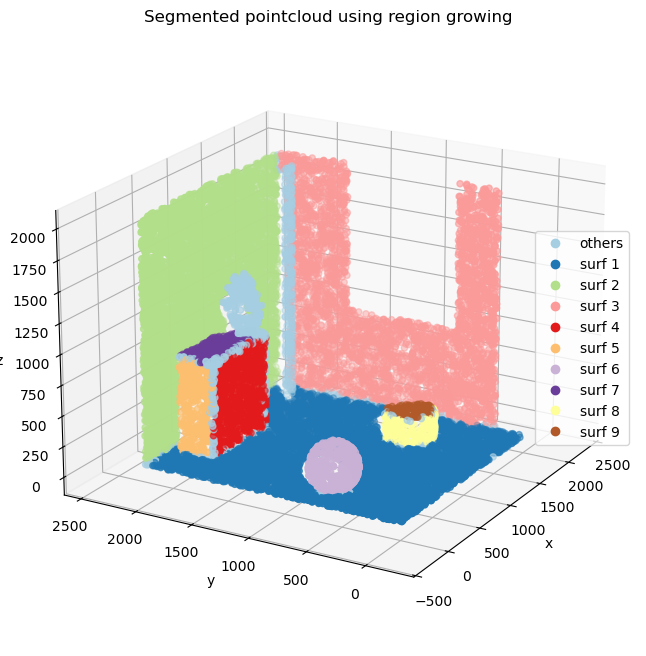

In [ ]:
# Segment pointcloud using region growing
regions = region_growing(points, normals, residuals, neighbor_finding_function,
                         angle_threshold, residual_threshold)    

# Attribute a label to each point (number of attributed region)
labels = np.zeros(len(points))
for i, r in enumerate(regions):
    if len(r) < 100: break # disregard small regions for vizualisation purpose
    labels[r] = i + 1
classes = ["surf {}".format(i) for i in range(len(np.unique(labels)))]
classes[0] = "others"

# Plot segmented pointcloud using region growing
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(points[:, 0], points[:, 1], points[:,2],
               c=labels, cmap="Paired")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right", handles=s.legend_elements()[0], labels=classes)
ax.view_init(20, 210)
plt.axis("equal")
plt.title("Segmented pointcloud using region growing")
plt.show()

Here, small neighborhoods and small thresholds (i.e., small values of $\theta_{th}$ and $r_{th}$) would likely lead to over-segmentation (i.e., more segmented surfaces), and vice-versa.

In a nutshell, the region-growth algorithm is relatively simple to conceptualize and implement. However, its results depend on the a priori definition of a neighborhoods and similarity criteria. Its parameters (size of the neighborhood and thresholds used to define the notion of similarity) need to be adjusted according to the context (pointcloud density, presence of noise, etc.).


### The Hough Transform

The Hough Transform is a technique used for detecting parametric shapes. It was introduced in the patent: Hough, P. V. C. (1962) *Method and Means for Recognizing Complex Patterns*, US Patent 3069654.

Its first application dealt with line detection in 2D images. It was later successfully extended to other 2D shapes, such as circles, but also to 3D shapes.

The Hough Transform **expresses any data point in the parameter space of the to-be-detected shape**. The computation of every set of parameters compatible with this data point gives a unique $m$-dimensional shape in the Hough space. As a result, the location of the point of intersection of $m$ or more shapes in the Hough space gives the parameters of the shape connecting the corresponding data points in the original space.

Let's consider a 3D plane. This plane is often described by its cartesian equation a.x + b.y + c.z + d = 0 with the first three parameters denoting its orientation (or normal) and the last one its signed distance to the origin. Switching to spherical coordinates, with $||r||=1$ to get a unit normal vector, leads to the much less often encountered equation 

\begin{equation*}
    x.\cos(\theta).\sin(\phi) + y.\sin(\theta).\sin(\phi) + z.\cos(\phi) = \rho
\end{equation*}

This has however the double advantage of reducing the number of parameters and also the parameter space. Indeed, the three parameters defining the orientation of the plane $a$, $b$ and $c$ have potentially infinite bounds (in practice unit normal vectors are often considered) while the two parameters $\theta$ and $\phi$ have finite bounds.

Regarding the parameter $\rho$, also note that its absolute value cannot exceed the distance to origin of the furthest point of the pointcloud. To put it simply:

\begin{equation*}
    | \rho | \leq \max \sqrt{x_i^2 + y_i^2 + z_i^2}
\end{equation*}

As a proof, consider that $|\rho| = |n \cdot p_i|$, with $n = (\cos(\theta).\sin(\phi), \sin(\theta).\sin(\phi), \cos(\phi))$ the plane normal and $p_i$ the point of the pointcloud through which the plane passes. Using the Cauchy-Schwarz inequality, we deduce that $|n \cdot p_i| \leq ||n||~||p_i||$. As $||n|| = 1$ here, we get $|\rho| = |n \cdot p_i| \leq ||p_i||$. Furthermore, it is possible to simply disconsider the orientation of the planes to avoid redudancy (in other words, consider that planes of equation $\rho = n \cdot p$ and $- \rho = - n \cdot p$ are the same plane). In practice, it means that $\rho \geq 0$, as a plane can always be positioned to intersect the origin.

As a result, a plane is usually described in a 3-dimensional Hough space with dimensions $\rho$, $\theta$, and $\phi$. This means that a point $q_j = [\rho_j, \theta_j, \phi_j]$ in the Hough space corresponds to a plane of equation $x.\cos(\theta_j).\sin(\phi_j) + y.\sin(\theta_j).\sin(\phi_j) + z.\cos(\phi_j) = \rho_j$ in the 3D space. On the opposite, in the 3D space, a point $p_i = [x_i, y_i, z_i]$ belongs to an infinite number of planes that verify the equation $x_i.\cos(\theta).\sin(\phi) + y_i.\sin(\theta).\sin(\phi) + z_i.\cos(\phi) = \rho$. Translating this in the Hough space results in drawing a three-dimensional sinusoid curve, like the ones shown below.

The Hough transform is then used to embed all $n$ points of the pointcloud in the Hough space, resulting in one sinusoid curve per point. The intersection of three curves in the Hough space corresponds to the coordinates defining the plane spanned by the three corresponding points. Of course, the more curves intersect the more points belong to this plane in the 3D space.


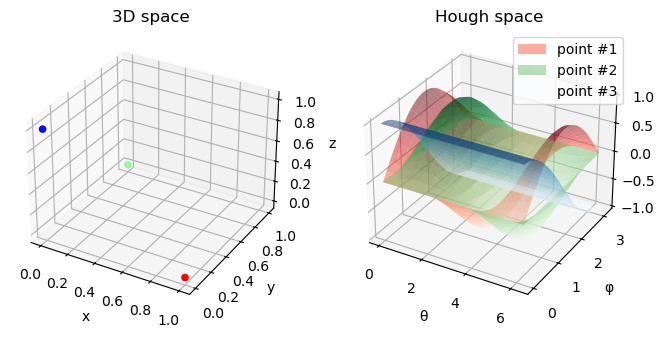

In [ ]:
def sample_hough_sinusoid_curve(point, n_theta=25, n_phi=25):
    """Build the unique sinusoid curve in the Hough space for a given point"""

    # Grid with theta and phi
    thetas = np.linspace(0., 2*np.pi, n_theta)
    phis = np.linspace(0., np.pi, n_phi)
    X, Y = np.meshgrid(thetas, phis)
    # Corresponding rho values
    ax = point[0] * np.cos(X) * np.sin(Y)
    by = point[1] * np.sin(X) * np.sin(Y)
    cz = point[2] * np.cos(Y)
    Z = ax + by + cz
    
    return X, Y, Z


# Example with three point
points_hough_example = np.array([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])
X, Y, Z_0 = sample_hough_sinusoid_curve(points_hough_example[0])
_, _, Z_1 = sample_hough_sinusoid_curve(points_hough_example[1])
_, _, Z_2 = sample_hough_sinusoid_curve(points_hough_example[2])

# Plot Hough sinusoid curves for three points
fig = plt.figure(figsize=(8, 6))
ax_0 = fig.add_subplot(121, projection="3d")
ax_0.scatter(
    points_hough_example[:, 0], points_hough_example[:, 1], points_hough_example[:, 2],
    c=points_hough_example
)
ax_0.set_xlabel('x')
ax_0.set_ylabel('y')
ax_0.set_zlabel('z')
ax_0.set_title("3D space")
ax_1 = fig.add_subplot(122, projection="3d")
ax_1.plot_surface(X, Y, Z_0, cmap="Reds", alpha=.5, label="point #1")
ax_1.plot_surface(X, Y, Z_1, cmap="Greens", alpha=.5, label="point #2")
ax_1.plot_surface(X, Y, Z_2, cmap="Blues", alpha=.5, label="point #3")
ax_1.set_xlabel('θ')
ax_1.set_ylabel('φ')
ax_1.set_zlabel('ρ')
ax_1.legend()
ax_1.set_title("Hough space")
plt.show()


Consequently, **detecting 3D planes with this technique involves finding intersections between sinusoid curves in Hough space**. Of course, the more curves are present at this intersection, the better. However, computing the intersections between $n$ curves (one per point) is in practice very computationally expensive. Moreover, points are likely to be affected by noise, which makes it almost impossible that several curves intersect at the exact same point in the Hough space.

In practice, the Hough space is discretized into $n_{\rho} * n_{\theta} * n_{\phi}$ cells or bins. Each bin is assigned a score representing the number of curves that pass through or, in other words, the number of points of the pointcloud that are compatible with the underlying plane parameters (with a tolerance due to discretization). For this reason, the underlying data structure (similar to a voxel grid here) is called the *accumulator*. As a result, **the shape detection process may be assimilated to a voting process, during which every data point "votes" for all sets of parameters that define a compatible plane**. In the end, the bins with the highest scores represent the planes compatible with the largest number of points.

Note that the size of the accumulator, which is usually an array of shape $(n_{\rho}, n_{\theta}, n_{\phi})$, has a direct impact on the plane detection process. Indeed, the larger this size, the smaller the cells, and the greater the chances of detecting different planes sharing almost the same parameters. However, the larger the accumulator size, the larger its memory footprint and the computation time required to fill it. For instance, choosing $n_{\theta} = 360$ and $n_{\phi} = 180$ so that $\theta_{step} = \phi_{step} = \pi/180$ results in $64800 * n_{\rho}$ cells. Consequently, a tradeoff must be found between the quality of the output of the detection process and the use of computational resources. In case the size of the accumulator cannot be reduced, using smaller unsigned integer types or a sparse matrix are some simple tricks to reduce its memory footprint.

Below is a tentative to detect the most important planes in our pointcloud thanks to the Hough Transform.


In [29]:
def hough_transform_plane(points, n_theta=120, n_phi=61, n_rho=None):
    """Hough Transform for plane detection.
    
    Parameters
    ----------
    points : (N, 3) ndarray
        Input pointcloud.
    n_theta : int
        Number of bins for the theta angle.
    n_phi : int
        Number of bins for the phi angle.
    n_rho : int or None
        Number of bins for the rho distance. If None, it is set to ceil(maximum distance).
        
    Returns
    -------
    accumulator : (n_theta, n_phi, n_rho) ndarray
        Hough accumulator array.
    theta_values : (n_theta,) ndarray
        Angles theta corresponding to the first dimension of the accumulator.
    phi_values : (n_phi,) ndarray
        Angles phi corresponding to the second dimension of the accumulator.
    rho_values : (n_rho,) ndarray
        Distances rho corresponding to the third dimension of the accumulator.
    """
    
    # Angles at which to compute the transform
    theta_values = np.linspace(0., 2*np.pi, n_theta, endpoint=False) # theta in [0., 2*pi[
    phi_values = np.linspace(0., np.pi, n_phi, endpoint=True) # phi in [0., pi]

    # Compute the bins
    rho_max = np.max(np.linalg.norm(points, axis=1))
    # Unit size by default
    if n_rho is None:
        rho_max = np.ceil(rho_max).astype(int)
        n_rho = rho_max + 1
    rho_values, rho_step = np.linspace(0., rho_max, n_rho, endpoint=True , retstep=True) # rho in [0, rho_max]

    # Allocate the accumulator array
    accumulator = np.zeros(
        (n_theta, n_phi, n_rho),
        dtype=np.uint16 # Use ushort to reduce memory footprint (/!\ count up to 65535 only!)
    )
    
    # Precompute normals to speed-up computation
    i = np.tile(np.arange(n_theta), n_phi) # grid indices for theta
    j = np.repeat(np.arange(n_phi), n_theta) # grid indices for phi
    normals = np.vstack([
        np.cos(theta_values[i]) * np.sin(phi_values[j]),
        np.sin(theta_values[i]) * np.sin(phi_values[j]),
        np.cos(phi_values[j])
    ])
    
    # Fill accumulator by computing rho values associated with (theta, phi) for each point
    for point in points:
        # Vectorized form of rho = a.x + b.y + c.z
        rho_calc = point @ normals
        # Compute the grid index associted with rho_calc
        k = (rho_calc//rho_step).astype(int)
        # Keep only indices associated with positive rho values (avoid redundancy)
        valid = (k >= 0)
        # Increment bins
        accumulator[i[valid], j[valid], k[valid]] += 1

    return accumulator, theta_values, phi_values, rho_values



In [ ]:
def bin_to_plane_parameters(acc_bin, theta_values, phi_values, rho_values):
    """Convert Hough bin indices to plane parameters (a, b, c, d)"""

    theta_idx, phi_idx, rho_idx = acc_bin

    theta = theta_values[theta_idx]
    phi = phi_values[phi_idx]
    rho = rho_values[rho_idx]
    
    a = np.cos(theta) * np.sin(phi)
    b = np.sin(theta) * np.sin(phi)
    c = np.cos(phi)
    d = rho
    
    return np.array([a, b, c, d])


# Transform our pointcloud
accumulator, theta_values, phi_values, rho_values = hough_transform_plane(points)
print(f"The accumulator consists of {accumulator.size} cells,",
      f"of which {np.count_nonzero(accumulator)} are not empty")

# Find the bins with the highest scores
n_best = 5
best_bins = [np.unravel_index(ind, accumulator.shape) 
             for ind in np.argpartition(accumulator.flatten(), -n_best)[-n_best:]]
print(f"The best {n_best} bins are: {[tuple(map(int, bin)) for bin in best_bins]}")

# Retrieve the parameters of the the detected planes
best_planes = [
    bin_to_plane_parameters(b, theta_values, phi_values, rho_values) 
    for b in best_bins
]
with np.printoptions(precision=4, suppress=True):
    print("Detected (cartesian) planes are:", best_planes)


The accumulator consists of 26352000 cells, of which 9532530 are not empty
The best 5 bins are: [(22, 60, 0), (17, 60, 0), (26, 60, 0), (2, 60, 0), (0, 30, 2000)]
Detected (cartesian) planes are: [array([ 0.,  0., -1.,  0.]), array([ 0.,  0., -1.,  0.]), array([ 0.,  0., -1.,  0.]), array([ 0.,  0., -1.,  0.]), array([   1.,    0.,    0., 2000.])]


As shown above, the result is a bit disappointing as the detection process returns containing many identical planes.

These planes correspond to adjacent cells in the accumulator, materialized by two vertical lines, as shown below. In this particular example, bins with the highest score correspond to parameters $\rho = 0$ and $\phi = 0 \pm \pi$, which corresponds to planes with equations $z = 0$ (note that the parameter $\theta$ doesn't come into play as $\cos \phi = 0$).


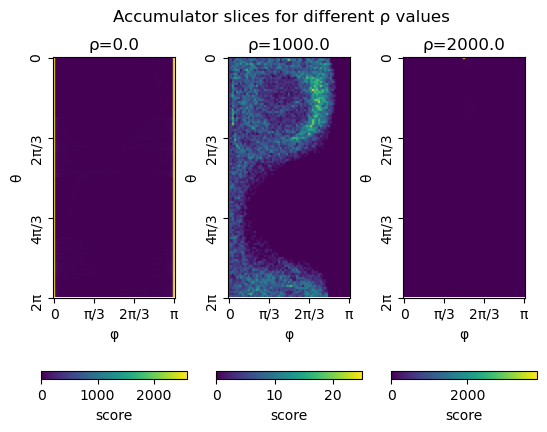

In [ ]:
# Show accumulator values for layer rho_index
rho_indices = [0, 1000, 2000]

fig, axes = plt.subplots(1, len(rho_indices))
for ax, rho_index in zip(axes, rho_indices):
    im = ax.imshow(accumulator[:,:,rho_index], cmap='viridis')
    cbar = fig.colorbar(im, ax=ax,
                        location="bottom", orientation="horizontal", pad=0.2)
    cbar.set_label('score')
    ax.set_xticks(np.linspace(0, len(phi_values)-1, 4))
    ax.set_xticklabels(["0", "π/3", "2π/3", "π"], rotation=0)
    ax.set_xlabel('φ')
    ax.set_yticks(np.linspace(0, len(theta_values), 4))
    ax.set_yticklabels(["0", "2π/3", "4π/3", "2π"], rotation=90)
    ax.set_ylabel('θ')
    ax.set_title(f"ρ={rho_values[rho_index]}")
fig.suptitle("Accumulator slices for different ρ values")
plt.show()

The problem described above is related to parameterization and the presence of points belonging to a perfectly horizontal plane. This is unlikely to occur in reality. A simple solution is to select bins with significant scores and remove duplicate planes, as described below.

Number of significant planes (score >= 500): 243
Number of unique significant planes: 5


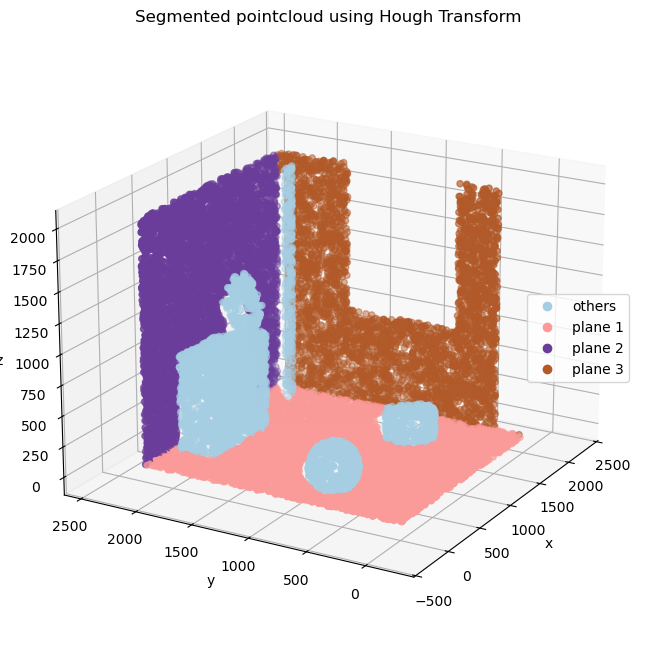

In [ ]:
# Find all bins/planes with a score higher than a given threshold
significant_bins = np.argwhere(accumulator >= 500)
significant_planes = [
    bin_to_plane_parameters(b, theta_values, phi_values, rho_values) 
    for b in significant_bins
]
print(f"Number of significant planes (score >= 500): {len(significant_planes)}")

# Remove duplicate planes by rounding parameters and keeping unique rows
significant_planes = np.round(significant_planes, decimals=4)
unique_significant_planes = np.unique(significant_planes, axis=0)
print(f"Number of unique significant planes: {len(unique_significant_planes)}")

# Label each point according to the detected planes
labels = np.zeros(len(points))
for i, plane_equation in enumerate(unique_significant_planes):
    dists = np.abs(points @ plane_equation[:3] - plane_equation[3])
    inliers = dists < 1. # Adjust in function of rho_step
    labels[inliers] = i + 1
classes = ["plane {}".format(i) for i in range(len(np.unique(labels)))]
classes[0] = "others"

# Plot segmented pointcloud using Hough Transform
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(points[:, 0], points[:, 1], points[:,2],
                c=labels, cmap="Paired")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right", handles=s.legend_elements()[0], labels=classes)
ax.view_init(20, 210)
plt.axis("equal")
plt.title("Segmented pointcloud using Hough Transform")
plt.show()



The above example underlines that maximum values or peaks are often spread around adjacent bins representing in fact a single plane. This may be due to parametrization, as illustrated here, but also often to discretization and noise. Indeed, if bins are too small or if points are affected by a large amount of noise, some votes are likely miss the "right" bin and fall into neighboring bins instead. 

This is why, it is advised to **not search for the best bins but for groups of adjacent bins with high scores instead**. A popular solution consists in refining the result of the Hough Transform with Non-Maximum Suppression. This technique basically relies on a notion of minimum distance separating peaks in each dimension.

A simple implementation of this technique is given below. The function filters out non-maximal values in the accumulator array by using a sliding window technique to identify local maxima and then applying a threshold to keep only significant peaks. This helps in reducing noise and focusing on the most prominent features in the data.


In [ ]:
def peak_window(accumulator, size_theta=5, size_phi=5, size_rho=3, threshold=None):
    """Use a sliding window technique to filter out the maxima in the accumulator
    that are close to each other."""

    acc = accumulator.copy()
    # Threshold is set to half the max value of the accumulator by default
    if threshold is None:
        threshold = 0.5 * np.max(accumulator)
    # Slide the window and only keep the maximum value
    acc_max = ndimage.maximum_filter(acc, size=(size_theta, size_phi, size_rho),
                                     mode="constant")
    # Create a mask to keep only the peaks
    mask = (acc == acc_max)
    # Apply the mask
    acc *= mask
    # Only keep peaks above the treshold
    acc[acc < threshold] = 0

    return acc


As show below, small peaks and bins with low scores are filtered. However, this has only little impact on vertical lines discussed above.

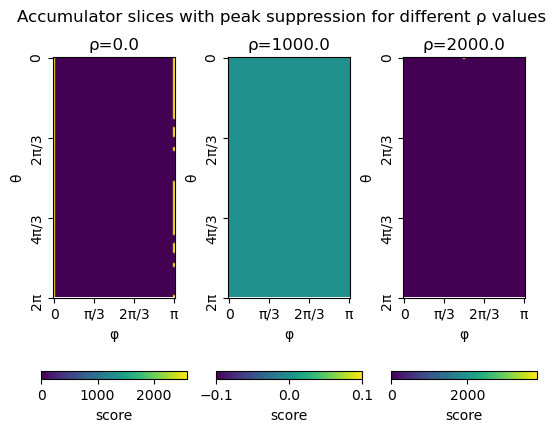

In [ ]:
# Apply our peak detection
new_accumulator = peak_window(accumulator)

# Show new accumulator values (with peak suppression) for layer rho_index
# (rho_indices defined above)
fig, axes = plt.subplots(1, len(rho_indices))
for ax, rho_index in zip(axes, rho_indices):
    im = ax.imshow(new_accumulator[:,:,rho_index], cmap='viridis')
    cbar = fig.colorbar(im, ax=ax,
                        location="bottom", orientation="horizontal", pad=0.2)
    cbar.set_label('score')
    ax.set_xticks(np.linspace(0, len(phi_values)-1, 4))
    ax.set_xticklabels(["0", "π/3", "2π/3", "π"], rotation=0)
    ax.set_xlabel('φ')
    ax.set_yticks(np.linspace(0, len(theta_values), 4))
    ax.set_yticklabels(["0", "2π/3", "4π/3", "2π"], rotation=90)
    ax.set_ylabel('θ')
    ax.set_title(f"ρ={rho_values[rho_index]}")
fig.suptitle("Accumulator slices with peak suppression for different ρ values")
plt.show()

Numerous variants of the Hough transform for plane detection have been proposed over the years to improve its performance. This article provides a good summary: Borrmann, D., Elseberg, J., Lingemann, K., & Nüchter, A. (2011). The 3D Hough Transform for plane detection in point clouds: A review and a new accumulator design. *3D Research*, 3(2), 1-13.

However, its extension to other 3D shapes remains quite difficult. This is mostly due to the higher number of parameters necessary for their description, which increases the dimensionality of the corresponding Hough space and results in a prohibitively high time and space complexity of the algorithm for most practical applications (this is also known as the curse of dimensionality).

Note that some tricks may be used to mitigate this aspect, as for example estimating the shape parameters in a sequential manner. This was successfully applied to cylinder detection, where a first 2D Hough Transform is used to estimate the cylinder orientation and a second 3D Hough Transform is used to estimate its position and radius. More details may be found in the paper: Rabbani, T., & Van Den Heuvel, F. (2005). Efficient Hough Transform for Automatic Detection of Cylinders in Point Clouds. *In Proceedings of the ISPRS Workshop "Laser Scanning 2005"*, 60-65.

Nevertheless, this exception seems to confirm the general rule that the Hough transform is not suited for the detection of most complex 3D shapes.

To sum up, the Hough Transform may be adapted to detect simple shapes such as planes in pointclouds. It is a relatively simple algorithm that is theoretically capable of detecting all the planes in the pointcloud at once (without needing to be iteratively applied). However, a tradeoff must be found between the precision of the algorithm (via the finesse of parameter space discretization) and the use of computing resources. Some post-processing steps may also be required to eliminate similar detected shapes.


### RANSAC

The Random sample consensus (RANSAC) algorithm aims to estimate the parameters of a *model* from a dataset that contains outliers. It was introduced in the paper: Fischler, M. A., & Bolles, R. C. (1981). Random sample consensus: a paradigm for model fitting with applications to image analysis and automated cartography. *Communications of the ACM*, 24(6), 381-395.

The basic algorithm consists in two steps, that are iteratively repeated:

1. Randomly draw a sample of minimum but sufficient size from the dataset to build a candidate model
2. Compute the score of this candidate model by estimating the number of elements of the dataset that are consistent with it

The best candidate model is kept after a given number of iterations.

The RANSAC algorithm has many applications, including finding geometrical shapes in pointclouds. As for models (in general), these shapes have parameters and a measure of "how far" they are from the data points. **The RANSAC algorithm therefore generates multiple candidate shapes from a few randomly selected points to only keep the "best shape" in the end**. It relies on the fact that generating and evaluating a candidate shape is computationally inexpensive and can be repeated a large number of times.

Let's consider an infinite planar surface, described by its cartesian equation $a.x + b.y + c.z + d = 0$,  for the sake of the example. The parameters of the plane ($a$, $b$, $c$, and $d$) may be estimated using 3 points only: $n = [a, b, c] = (p_1 - p_0) \times (p_2 - p_0)$ and $d = - p_i \cdot n, \quad i = 0, 1, 2$. The distance between a point $p$ and the plane is given by $d = | n \cdot p + d |$ with $|| n || = 1$.


In [35]:
class PlaneModel:
    """Plane model for RANSAC plane fitting."""

    # Minimum number of points to estimate the model
    min_sample_size = 3
    
    def __init__(self):

        # Parameters of the model
        # Here (a, b, c, d) of the plane equation a.x + b.y + c.z + d = 0
        self.parameters = [1., 0., 0., 0.]

    def estimate_parameters(self, points):
        """Build plane model from three points"""

        v1, v2 = points[1, :] - points[0, :], points[2, :] - points[0, :]
        self.parameters[:3] = np.cross(v1, v2) / np.linalg.norm(np.cross(v1, v2))
        self.parameters[-1] = - points[0, :] @ self.parameters[:3]

    def compute_distance(self, points):
        """Compute distance between the plane and the given points"""

        return np.abs(points @ self.parameters[:3] + self.parameters[-1])


A given number of candidate planes are evaluated before the best candidate is returned. Inliers are defined as points within a certain distance (threshold) to a candidate plane.

The algorithm then is usually repeated a certain number of times in order to detect all shapes present in the pointcloud.


In [ ]:
def RANSAC(points, model, n_draws, threshold):
    """RANSAC algorithm.
    
    Parameters
    ----------
    points : ndarray of shape (n_points, 3)
        Input pointcloud.
    model : class
        Model class with methods estimate_parameters and compute_distance.
    n_draws : int
        Number of random samples to draw.
    threshold : float
        Distance threshold to consider a point as an inlier.

    Returns
    -------
    best_model : instance of model
        Best model found.
    best_score : int
        Number of inliers of the best model.
    best_inliers : ndarray of shape (n_inliers,)
        Indices of the inliers of the best model.
    """

    best_score = 0
    best_model = None
    best_inliers = None

    for _ in range(n_draws):
        # Random sampling
        sampled_inds = np.random.choice(len(points), size=model.min_sample_size,
                                        replace=False)
        sampled_points = points[sampled_inds]
        # Candidate plane
        candidate = model()
        candidate.estimate_parameters(sampled_points)
        # Inliers
        dists = candidate.compute_distance(points)
        inliers = np.flatnonzero(dists < threshold)
        # Score
        score = len(inliers)
        # Keep best candidate
        if score > best_score:
            best_score = score
            best_model = candidate
            best_inliers = inliers

    return best_model, best_score, best_inliers


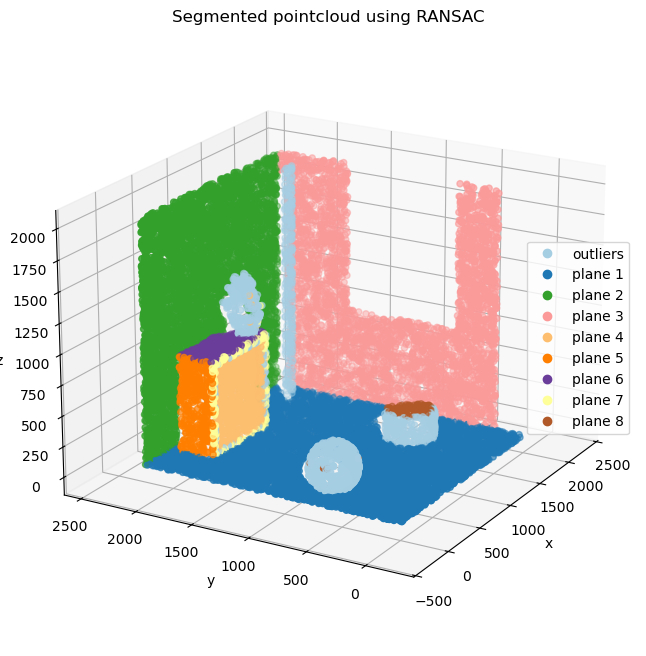

In [37]:
# Run RANSAC for planar surfaces
max_number_of_runs = 100
min_points_per_region = 100 # disregard small regions

ransac_planes = []
ransac_scores = []
ransac_regions = []
remaining_inds = np.arange(len(points), dtype=int)
for _ in range(max_number_of_runs):
    model, score, inliers = RANSAC(points[remaining_inds], PlaneModel, 100, 1.)
    if len(inliers) > min_points_per_region:
        ransac_planes.append(model)
        ransac_scores.append(score)
        ransac_regions.append(remaining_inds[inliers])
        remaining_inds = np.setdiff1d(remaining_inds, remaining_inds[inliers])

# Attribute a label to each point (number of attributed region)
labels = np.zeros(len(points))
for i, r in enumerate(ransac_regions):
    labels[r] = i+1
classes = ["plane {}".format(i) for i in range(len(np.unique(labels)))]
classes[0] = "outliers"

# Plot segmented pointcloud using RANSAC
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
              c=labels, cmap="Paired")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right", handles=s.legend_elements()[0], labels=classes)
ax.view_init(20, 210)
plt.axis("equal")
plt.title("Segmented pointcloud using RANSAC")
plt.show()


As seen above, the algorithm successfully detect planar surfaces in the pointcloud. Again, the parameters of the algorithm can be adjusted according to the segmentation result: a small number of repetitions and a small value of the distance threshold would likely lead to under-segmentation, and vice-versa.

The above example describes a very simple implementation of the RANSAC algorithm, but many proposals have been made to improve its the behavior in the context of shape detection in pointclouds. Some major ones are described in the article: Schnabel, R., Wahl, R., & Klein, R. (2007, June). Efficient RANSAC for point‐cloud shape detection. In *Computer graphics forum* (Vol. 26, No. 2, pp. 214-226). Oxford, UK: Blackwell Publishing Ltd.

Covered aspects include shape estimation (i.e., the process of estimating the parameters of planes, cylinders, spheres, cones and tori from minimal sets of oriented points), complexity (i.e., the number of candidates required to detect shapes with sufficient probability), sampling strategy, scoring (using a distance threshold but also an angular threshold and taking points connectivity into account), and refitting.

More generally, the popularity of the RANSAC algorithm for shapes detection in pointclouds lies in its simplicity, extensibility to a wide variety of shapes (as long as an estimation function from a minimal set of points and a distance function are available) and robustness to the presence of outliers. However, it is quite computationally demanding and non-deterministic (i.e., different runs may give different results).



## Object segmentation

The object segmentation technique described here is fairly simple and relies on the notion of spatial proximity to group points belonging to individual objects. In simpler terms, it assumes that points belonging to the same object are "close" to each other while points belonging to distinct objects are "far" from each other. This assumption holds across a variety of environments, including indoor, natural, and urban scenes, where physical elements such as furniture, vegetation, buildings, and vehicles typically exhibit clear spatial boundaries.

It is difficult to trace the origin of this technique, which is probably derived from image processing. One implementation is found in the Point Cloud Library (PCL) under the name of `EuclideanClusterExtraction`. The description of the underlying algorithm is taken from the following PhD thesis: Rusu, R. B. (2009). Semantic 3D object maps for everyday manipulation in human living environments. *PhD thesis from Technische Universitaet Muenchen*. It may be seen as a simplified version of the Region growing algorithm described above, only considering a proximity criterion (without normals compatibility). Note that this algorithm could easily be modified to integrate other criteria such as colors compatibility.

Alternatively, a more direct approach could be used by **modeling the point cloud as a graph to capture local spatial relationships**. It typically involves two main steps:

1. **Graph Construction**: A *nearest neighbors graph* is built, connecting each point and its closest neighbors.

2. **Connected Component Extraction**: Groups of points that are mutually reachable through the edges of the graph are identified and assumed to represent distinct objects.

The first step is typically carried out using a data stucture such an octree or a kdtree (see notebook about *spatial indexing*). The `scipy` library offers a very convenient implementation of a kdtree, having a `sparse_distance_matrix` method allowing to compute a distance matrix between two kdtrees (here the kdtree built from the pointcloud and itself) with a maximum distance parameter. Likewise, `scipy` offers a `connected_components` function to find the connected components of a sparse graph, so a custom implementation is not needed.

Note that **a preprocessing step is usually required for this segmentation algorithm to work**. Indeed, objects are usually connected by some *background* or *support surfaces*. These are typically large horizontal planes such as the ground, floors or even tabletops. Large vertical planes such as building facades and walls may also be considered. The removal of points belonging to such support surfaces is commonly achieved using plane detection techniques (usually RANSAC) or height-based thresholds.


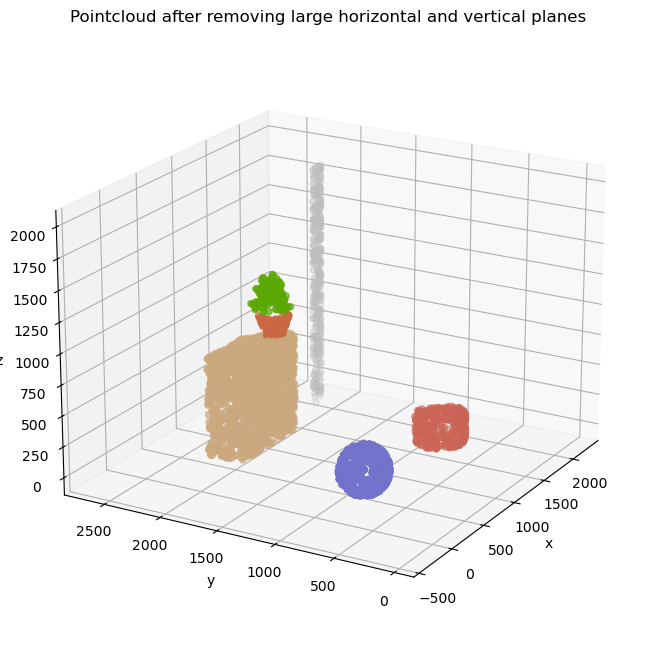

In [ ]:
# Preprocessing: remove suport planes
# 1. Extract points belonging to large horizontal and vertical planes
support_planes_inds = []
for model, score, inliers in zip(ransac_planes, ransac_scores, ransac_regions):
    # Check if plane is horizontal or vertical
    n_z = np.abs(model.parameters[3]) # z component of the normal
    if (n_z > 0.9 or n_z < 0.1) and score > 1000:
        # Mark inliers as outliers in the labels
        support_planes_inds.append(inliers)
# 2. Remove support plane points from the pointcloud
support_planes_inds = np.concatenate(support_planes_inds)
remaining_inds = np.setdiff1d(np.arange(len(points)), support_planes_inds)

# Plot remaining points
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
ax.scatter(
    points[remaining_inds, 0], points[remaining_inds, 1], points[remaining_inds, 2],
    c=colors[remaining_inds]
)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(20, 210)
plt.axis("equal")
plt.title("Pointcloud after removing large horizontal and vertical planes")
plt.show()


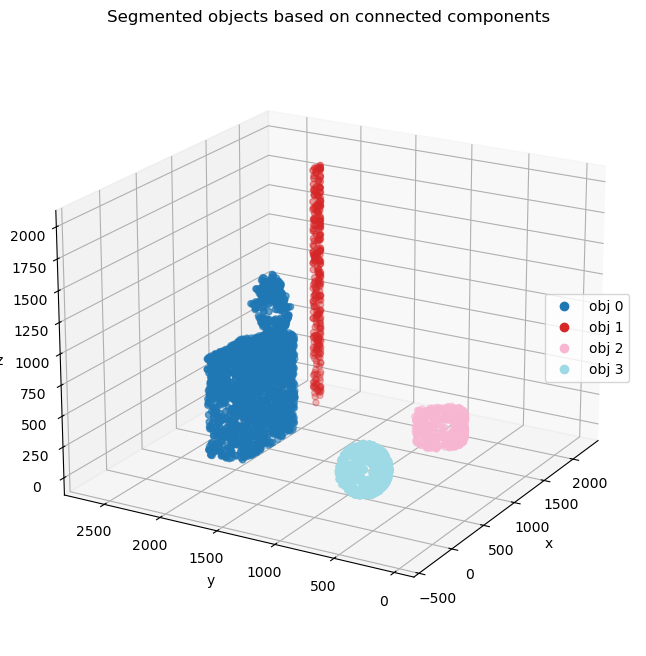

In [ ]:
# Find connected components based on euclidean distance
kdtree = KDTree(points[remaining_inds])
nn_graph = kdtree.sparse_distance_matrix(kdtree, max_distance=100.)
n_components, labels = connected_components(nn_graph, directed=False)

# Plot connected components
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
s = ax.scatter(
    points[remaining_inds, 0], points[remaining_inds, 1], points[remaining_inds, 2],
    c=labels, cmap="tab20"
)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right", handles=s.legend_elements()[0],
          labels=["obj {}".format(i) for i in range(n_components)])
ax.view_init(20, 210)
plt.axis("equal")
plt.title("Segmented objects based on connected components")
plt.show()

In summary, despite its apparent simplicity, this technique is capable of segmenting objects in rather complex scenes without the use of "learning algorithms".

## Wrapping up

You should now have a better grasp of some of the most popular surface segmentation algorithms: Region Growing, the Hough Transform, and RANSAC. Unlike newer learning algorithms, these rely solely on geometrical reasoning and *a priori* assumptions about the segments to be found. The results are group points belonging to locally smooth surfaces in case of Region Growing or to geometric primitives in case of the Hough Transform or RANSAC.

Each of these algorithms has its strengths and weaknesses. In short, Region Growing is a fairly simple algorithm that only requires a certain degree of smoothness of the underlying surface and guarantees that the segmented points are all within a certain predefined distance from each other. The fact that it operates at a local scale makes it rather sensitive to the presence of occlusions, noise and outliers. In constrast, the Hough Transform is more complex but also more robust and capable of detecting all shapes at once. It is in practice mostly adapted to planar shapes and may require consequent computational resources and additional post-processing steps to ensure the result consistency. Finally, RANSAC is a simple but robust algorithm that can be extended to detect many types of parametric shapes. It is, however, non-deterministic, quite computationally expensive due to its iterative nature, and has many parameters to tune in its most advanced form.

Surface segmentation algorithms may also be used to filter parts of the pointcloud of lesser importance such as points belonging to *background* or *support surfaces* to enable simple object segmentation. The most straightforward technique relies on points proximity and uses nearest neighbors’ graphs and connected components to segment objects. Although quite effective, it is also sensitive to pointcloud density and the presence of occlusions, noise, and outliers.

A key takeaway is that all these algorithms require an extensive phase of manual fine-tuning and are likely to achieve imperfect results on complex pointclouds. This is because they are based on quite simple assumptions and reasoning (e.g., the scene is composed of smooth surfaces and variation of orientation between neighboring points is enough to capture surface smoothness) and on a prior estimation of the pointcloud characteristics (e.g., density and noise). Although imperfect, these results may nevertheless be sufficient for subsequent processing tasks. In practice, manual rework is often required.

All these reasons partly explain the recent shift from these "traditional" or geometry-based surface segmentation algorithms to machine-learning-based and deep-learning-based ones. The latter are indeed capable of segmenting and classifying points according to more global or abstract criteria. This is the topic of a future notebook. Before that, the next chapter deals with surface fitting or how to retreive the parameters of segmented surfaces.
